#Additional Implementation

The additional implementation focuses on extending the safety evaluation of the CARLA perception system beyond the mandatory course excercises.
The experiments implemented in the python notebook are as follows:

1. Robustness to realistic input degradation,
2. Identification of a safety operating envelope,
3. Runtime mitigation when model reliability is insufficient, and
4. Traceability of the additional evidence to the existing safety case.

1) Input Corruption Robustness

This experiment evaluates how robus the three CARLA perception models are when the input images are affected by relaistic visual degradations where the test dataset images are modified with controlled corruption such as blur,redudced brightness, reduced contrast, and Gaussian noise.

In [1]:
# We use the same libraries and PyTorch setup as the previous exercises.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)


# We keep the additional results separate from the individual exercises.

RESULTS_DIR = "../results/additional_implementation"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)
print("Results will be saved to:", RESULTS_DIR)

Device: cpu
Results will be saved to: ../results/additional_implementation


In [3]:
# These are the same test-data locations used in the previous exercises.

TEST_DIR = "../datasets/test/rgb-front"

TEST_LABELS = "../datasets/test/labels.csv"


# Load the labels for the existing in-distribution test set.

test_df = pd.read_csv(
    TEST_LABELS
)

print(
    "Number of test images:",
    len(test_df)
)

print(
    "Test label columns:",
    list(test_df.columns)
)

Number of test images: 3600
Test label columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


In [4]:
# This is the original dataset class used in the previous exercises.
# We keep the same resizing and tensor conversion.

class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target
    ):

        self.df = dataframe

        self.image_dir = image_dir

        self.target = target

        self.transform = transforms.Compose([

            transforms.Resize((224, 224)),

            transforms.ToTensor()

        ])


    def __len__(self):

        return len(self.df)


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        frame = row["frame"]

        filename = f"{frame:06d}.jpg"

        path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(
            path
        ).convert("RGB")

        image = self.transform(
            image
        )

        label = float(
            row[self.target]
        )

        return image, label

In [5]:
# The same test images are evaluated for all three perception tasks.

ped_test = CarlaDataset(
    test_df,
    TEST_DIR,
    "has_pedestrian"
)

vehicle_test = CarlaDataset(
    test_df,
    TEST_DIR,
    "has_vehicle"
)

traffic_test = CarlaDataset(
    test_df,
    TEST_DIR,
    "has_traffic_light"
)


print(
    "Pedestrian test samples:",
    len(ped_test)
)

print(
    "Vehicle test samples:",
    len(vehicle_test)
)

print(
    "Traffic-light test samples:",
    len(traffic_test)
)

Pedestrian test samples: 3600
Vehicle test samples: 3600
Traffic-light test samples: 3600


In [6]:
#Input Corruption Robustness Implementation
#4 corruption types - [Gaussian Blur, Brightness Reduction, Gaussian Noise, COntrast Reduction] where each has three severity levels

# These functions modify an already resized image tensor.
# The label is never changed because the corruption only affects the image.

def apply_corruption(
    image,
    corruption,
    severity
):

    # Blur makes the camera image less sharp.

    if corruption == "blur":

        kernel_sizes = {
            1: 3,
            2: 7,
            3: 11
        }

        kernel_size = kernel_sizes[severity]

        image = TF.gaussian_blur(
            image,
            kernel_size=kernel_size
        )


    # Brightness reduction simulates darker camera conditions.

    elif corruption == "brightness":

        brightness_factors = {
            1: 0.8,
            2: 0.5,
            3: 0.3
        }

        image = TF.adjust_brightness(
            image,
            brightness_factors[severity]
        )


    # Contrast reduction makes objects less visually distinct.

    elif corruption == "contrast":

        contrast_factors = {
            1: 0.8,
            2: 0.5,
            3: 0.3
        }

        image = TF.adjust_contrast(
            image,
            contrast_factors[severity]
        )


    # Gaussian noise simulates noisy image acquisition.

    elif corruption == "noise":

        noise_levels = {
            1: 0.03,
            2: 0.08,
            3: 0.15
        }

        noise = torch.randn_like(
            image
        ) * noise_levels[severity]

        image = image + noise

        # Keep pixel values in the valid [0, 1] range.

        image = torch.clamp(
            image,
            0.0,
            1.0
        )


    return image

In [7]:
# This dataset keeps the original CARLA labels but applies a selected
# corruption to the image before it is given to the model.

class CorruptedCarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target,
        corruption=None,
        severity=None
    ):

        self.df = dataframe

        self.image_dir = image_dir

        self.target = target

        self.corruption = corruption

        self.severity = severity

        self.transform = transforms.Compose([

            transforms.Resize((224, 224)),

            transforms.ToTensor()

        ])


    def __len__(self):

        return len(self.df)


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        frame = row["frame"]

        filename = f"{frame:06d}.jpg"

        path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(
            path
        ).convert("RGB")

        # First apply exactly the same preprocessing as before.

        image = self.transform(
            image
        )

        # Then apply the artificial corruption.

        if self.corruption is not None:

            image = apply_corruption(
                image,
                self.corruption,
                self.severity
            )

        label = float(
            row[self.target]
        )

        return image, label

In [8]:
# This is the same ResNet-18 loading procedure used in Exercises 6, 7 and 9.

def load_model(
    model_path
):

    model = models.resnet18(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    model = model.to(
        device
    )

    model.eval()

    return model

In [9]:
# Load the three trained perception models.

pedestrian_model = load_model(
    "../models/pedestrian_model.pth"
)

vehicle_model = load_model(
    "../models/vehicle_model.pth"
)

traffic_model = load_model(
    "../models/traffic_light_model.pth"
)


print("All three models loaded successfully.")

All three models loaded successfully.


In [10]:
# Each model is connected to its corresponding target label.

models_info = [

    (
        "Pedestrian",
        pedestrian_model,
        "has_pedestrian"
    ),

    (
        "Vehicle",
        vehicle_model,
        "has_vehicle"
    ),

    (
        "Traffic Light",
        traffic_model,
        "has_traffic_light"
    )

]


for model_name, model, target in models_info:

    print(
        f"{model_name} model ready."
    )

Pedestrian model ready.
Vehicle model ready.
Traffic Light model ready.


In [11]:
# Evaluate one model on one clean or corrupted dataset.

def evaluate_model(
    model,
    dataset,
    batch_size=64
):

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    predictions = []

    true_labels = []

    confidences = []


    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device
            )

            outputs = model(
                images
            )

            probabilities = torch.sigmoid(
                outputs
            ).flatten()


            # The existing project uses 0.5 as the standard decision threshold.

            preds = (
                probabilities > 0.5
            ).cpu().numpy()


            predictions.extend(
                preds
            )

            true_labels.extend(
                labels.numpy()
            )


            # MSP-style confidence for the binary classifier.

            batch_confidence = torch.maximum(
                probabilities,
                1 - probabilities
            )

            confidences.extend(
                batch_confidence.cpu().numpy()
            )


    predictions = np.array(
        predictions
    ).astype(int)


    true_labels = np.array(
        true_labels
    ).astype(int)


    confidences = np.array(
        confidences
    )


    accuracy = accuracy_score(
        true_labels,
        predictions
    )


    precision = precision_score(
        true_labels,
        predictions,
        zero_division=0
    )


    recall = recall_score(
        true_labels,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        true_labels,
        predictions,
        zero_division=0
    )


    mean_confidence = np.mean(
        confidences
    )


    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Mean Confidence": mean_confidence
    }

In [12]:
# First evaluate the original, unmodified test set.
# This gives us the baseline for every later corruption.

clean_results = []


for model_name, model, target in models_info:

    print(
        f"\nEvaluating clean test set: {model_name}"
    )


    dataset = CarlaDataset(
        test_df,
        TEST_DIR,
        target
    )


    metrics = evaluate_model(
        model,
        dataset
    )


    clean_results.append({

        "Model": model_name,

        "Corruption": "None",

        "Severity": 0,

        **metrics

    })


clean_results_df = pd.DataFrame(
    clean_results
)


clean_results_df


Evaluating clean test set: Pedestrian

Evaluating clean test set: Vehicle

Evaluating clean test set: Traffic Light


,Model,Corruption,Severity,Accuracy,Precision,Recall,F1,Mean Confidence
0,Pedestrian,None,0,0.716389,0.347826,0.509915,0.413555,0.840395
1,Vehicle,None,0,0.819444,0.824162,0.965185,0.889116,0.921419
2,Traffic Light,None,0,0.939444,0.934926,0.984133,0.958899,0.986456


In [13]:
# Three severity levels are used for each corruption.
# This lets us see whether performance degrades gradually.

corruptions = {

    "blur": [1, 2, 3],

    "brightness": [1, 2, 3],

    "contrast": [1, 2, 3],

    "noise": [1, 2, 3]

}


print(
    "Corruptions to evaluate:"
)

for corruption, levels in corruptions.items():

    print(
        corruption,
        "→ severity",
        levels
    )

Corruptions to evaluate:
blur → severity [1, 2, 3]
brightness → severity [1, 2, 3]
contrast → severity [1, 2, 3]
noise → severity [1, 2, 3]


In [14]:
# Now evaluate all three models under every corruption and severity level.

icr_results = []


for model_name, model, target in models_info:

    print(
        f"\n=============================="
    )

    print(
        f"Model: {model_name}"
    )

    print(
        f"=============================="
    )


    # Get the clean recall for this model.

    clean_recall = clean_results_df.loc[
        clean_results_df["Model"] == model_name,
        "Recall"
    ].iloc[0]


    for corruption, severity_levels in corruptions.items():

        for severity in severity_levels:

            print(
                f"Testing {corruption}, severity {severity}"
            )


            dataset = CorruptedCarlaDataset(

                test_df,

                TEST_DIR,

                target,

                corruption,

                severity

            )


            metrics = evaluate_model(

                model,

                dataset

            )


            # Recall drop is calculated in the same spirit as Exercise 8.

            recall_drop = (
                clean_recall
                - metrics["Recall"]
            )


            icr_results.append({

                "Model": model_name,

                "Corruption": corruption,

                "Severity": severity,

                "Accuracy": metrics["Accuracy"],

                "Precision": metrics["Precision"],

                "Recall": metrics["Recall"],

                "F1": metrics["F1"],

                "Mean Confidence": metrics["Mean Confidence"],

                "Recall Drop": recall_drop

            })


icr_results_df = pd.DataFrame(
    icr_results
)


print(
    "\nICR evaluation completed."
)

icr_results_df.head()


Model: Pedestrian
Testing blur, severity 1
Testing blur, severity 2
Testing blur, severity 3
Testing brightness, severity 1
Testing brightness, severity 2
Testing brightness, severity 3
Testing contrast, severity 1
Testing contrast, severity 2
Testing contrast, severity 3
Testing noise, severity 1
Testing noise, severity 2
Testing noise, severity 3

Model: Vehicle
Testing blur, severity 1
Testing blur, severity 2
Testing blur, severity 3
Testing brightness, severity 1
Testing brightness, severity 2
Testing brightness, severity 3
Testing contrast, severity 1
Testing contrast, severity 2
Testing contrast, severity 3
Testing noise, severity 1
Testing noise, severity 2
Testing noise, severity 3

Model: Traffic Light
Testing blur, severity 1
Testing blur, severity 2
Testing blur, severity 3
Testing brightness, severity 1
Testing brightness, severity 2
Testing brightness, severity 3
Testing contrast, severity 1
Testing contrast, severity 2
Testing contrast, severity 3
Testing noise, severit

,Model,Corruption,Severity,Accuracy,Precision,Recall,F1,Mean Confidence,Recall Drop
0,Pedestrian,blur,1,0.814444,0.555556,0.269122,0.362595,0.904778,0.240793
1,Pedestrian,blur,2,0.818611,0.873239,0.087819,0.159588,0.970913,0.422096
2,Pedestrian,blur,3,0.810000,1.000000,0.031161,0.060440,0.985868,0.478754
3,Pedestrian,brightness,1,0.773611,0.425240,0.439093,0.432056,0.853809,0.070822
4,Pedestrian,brightness,2,0.817778,0.678571,0.134561,0.224586,0.948832,0.375354


In [ ]:
# Add the clean baseline to the corruption results so everything


clean_for_icr = clean_results_df.copy()


clean_for_icr["Recall Drop"] = 0.0


all_icr_results = pd.concat(

    [
        clean_for_icr,
        icr_results_df
    ],

    ignore_index=True

)


all_icr_results

,Model,Corruption,Severity,Accuracy,Precision,Recall,F1,Mean Confidence,Recall Drop
0,Pedestrian,None,0,0.716389,0.347826,0.509915,0.413555,0.840395,0.000000
1,Vehicle,None,0,0.819444,0.824162,0.965185,0.889116,0.921419,0.000000
2,Traffic Light,None,0,0.939444,0.934926,0.984133,0.958899,0.986456,0.000000
3,Pedestrian,blur,1,0.814444,0.555556,0.269122,0.362595,0.904778,0.240793
4,Pedestrian,blur,2,0.818611,0.873239,0.087819,0.159588,0.970913,0.422096
5,Pedestrian,blur,3,0.810000,1.000000,0.031161,0.060440,0.985868,0.478754
6,Pedestrian,brightness,1,0.773611,0.425240,0.439093,0.432056,0.853809,0.070822
7,Pedestrian,brightness,2,0.817778,0.678571,0.134561,0.224586,0.948832,0.375354
8,Pedestrian,brightness,3,0.805278,0.857143,0.008499,0.016830,0.963794,0.501416
9,Pedestrian,contrast,1,0.762778,0.402116,0.430595,0.415869,0.839100,0.079320


In [16]:
#Saving the values

icr_csv_path = os.path.join(

    RESULTS_DIR,

    "input_corruption_robustness_results.csv"

)


all_icr_results.to_csv(

    icr_csv_path,

    index=False

)


print(
    "ICR results saved to:"
)

print(
    icr_csv_path
)

ICR results saved to:
../results/additional_implementation\input_corruption_robustness_results.csv


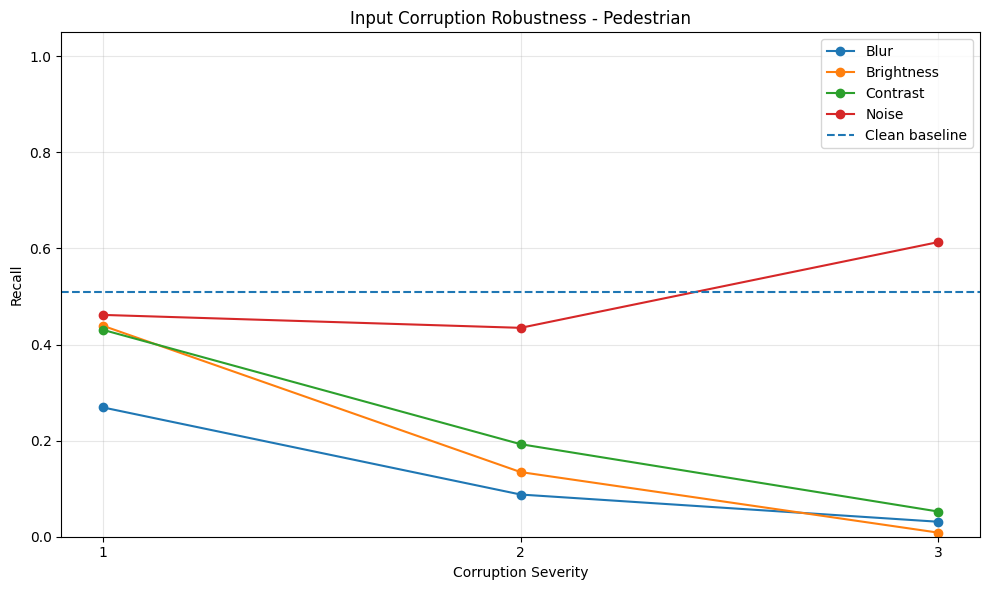

Saved: ../results/additional_implementation\pedestrian_icr_recall.png


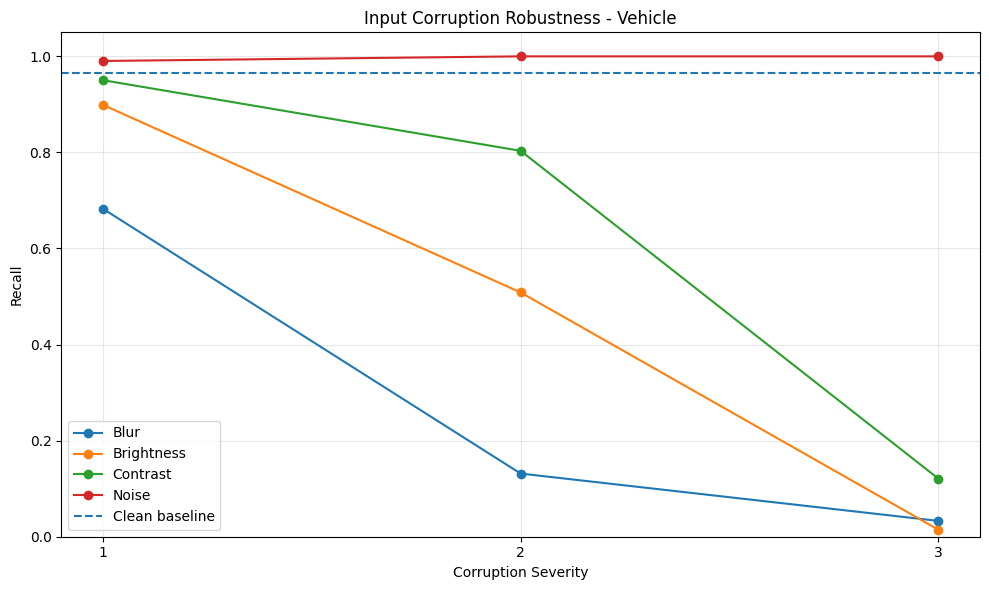

Saved: ../results/additional_implementation\vehicle_icr_recall.png


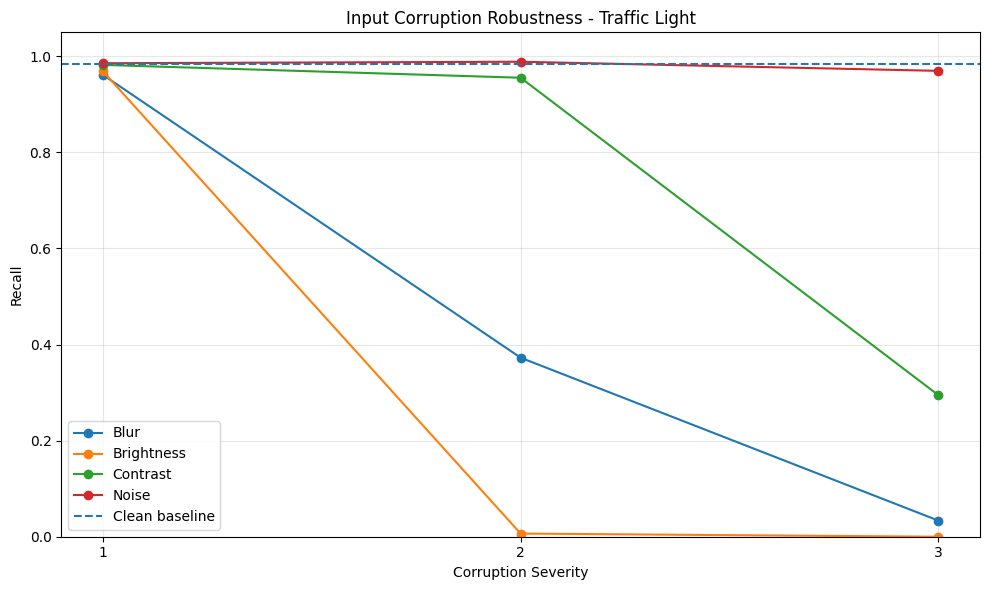

Saved: ../results/additional_implementation\traffic_light_icr_recall.png


In [17]:
# Recall is the main safety metric, so plotting how it changes
# as the corruption becomes more severe.

for model_name in all_icr_results["Model"].unique():

    model_data = all_icr_results[
        all_icr_results["Model"] == model_name
    ]


    plt.figure(
        figsize=(10, 6)
    )


    for corruption in corruptions.keys():

        corruption_data = model_data[
            model_data["Corruption"] == corruption
        ]


        plt.plot(

            corruption_data["Severity"],

            corruption_data["Recall"],

            marker="o",

            label=corruption.capitalize()

        )


    # Add the clean baseline as a reference.

    clean_recall = model_data[
        model_data["Corruption"] == "None"
    ]["Recall"].iloc[0]


    plt.axhline(

        clean_recall,

        linestyle="--",

        label="Clean baseline"

    )


    plt.xlabel(
        "Corruption Severity"
    )

    plt.ylabel(
        "Recall"
    )

    plt.title(
        f"Input Corruption Robustness - {model_name}"
    )

    plt.xticks(
        [1, 2, 3]
    )

    plt.ylim(
        0,
        1.05
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    filename = (

        model_name.lower()
        .replace(" ", "_")
        + "_icr_recall.png"

    )


    output_path = os.path.join(

        RESULTS_DIR,

        filename

    )


    plt.savefig(

        output_path,

        bbox_inches="tight"

    )


    plt.show()

    plt.close()


    print(
        "Saved:",
        output_path
    )

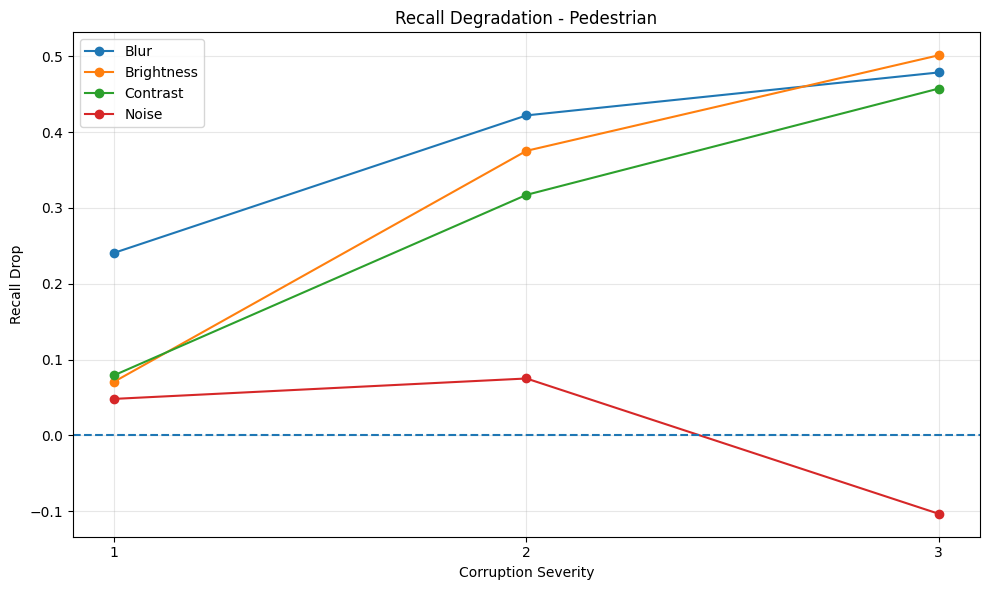

Saved: ../results/additional_implementation\pedestrian_icr_recall_drop.png


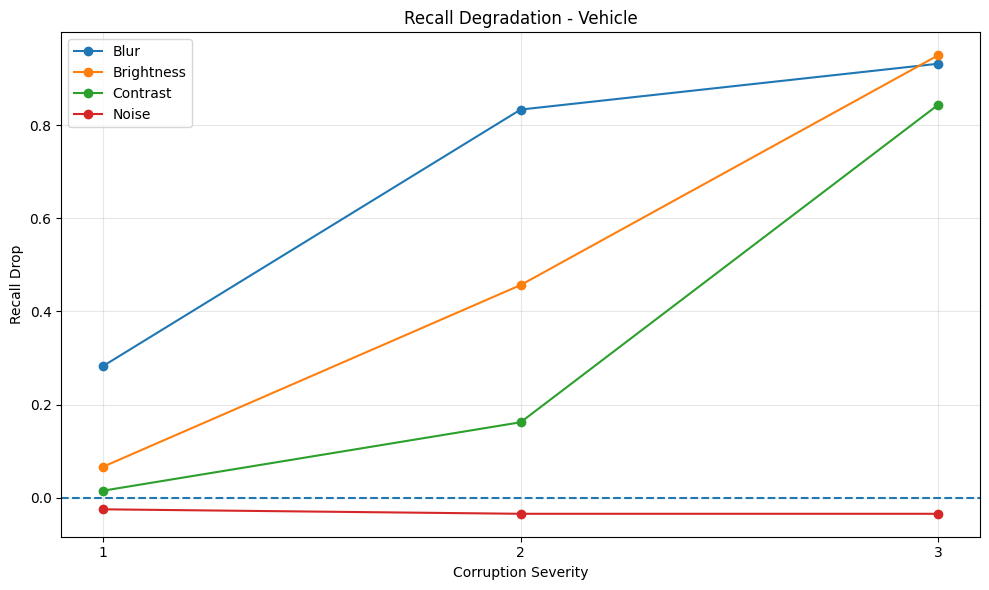

Saved: ../results/additional_implementation\vehicle_icr_recall_drop.png


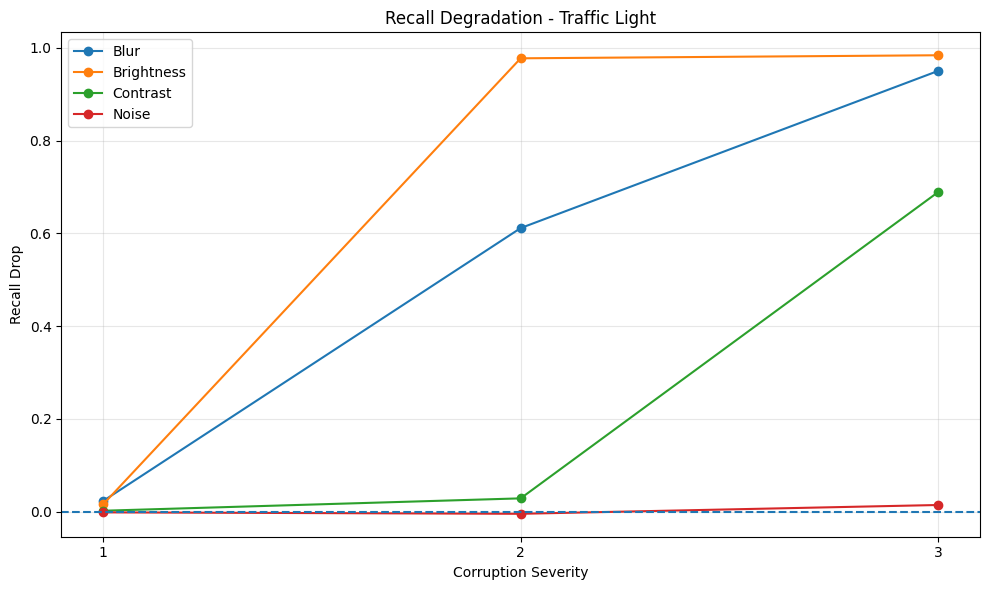

Saved: ../results/additional_implementation\traffic_light_icr_recall_drop.png


In [18]:
#Recall drop comparison

for model_name in icr_results_df["Model"].unique():

    model_data = icr_results_df[
        icr_results_df["Model"] == model_name
    ]


    plt.figure(
        figsize=(10, 6)
    )


    for corruption in corruptions.keys():

        corruption_data = model_data[
            model_data["Corruption"] == corruption
        ]


        plt.plot(

            corruption_data["Severity"],

            corruption_data["Recall Drop"],

            marker="o",

            label=corruption.capitalize()

        )


    plt.axhline(

        0,

        linestyle="--"

    )


    plt.xlabel(
        "Corruption Severity"
    )

    plt.ylabel(
        "Recall Drop"
    )

    plt.title(
        f"Recall Degradation - {model_name}"
    )

    plt.xticks(
        [1, 2, 3]
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    filename = (

        model_name.lower()
        .replace(" ", "_")
        + "_icr_recall_drop.png"

    )


    output_path = os.path.join(

        RESULTS_DIR,

        filename

    )


    plt.savefig(

        output_path,

        bbox_inches="tight"

    )


    plt.show()

    plt.close()


    print(
        "Saved:",
        output_path
    )

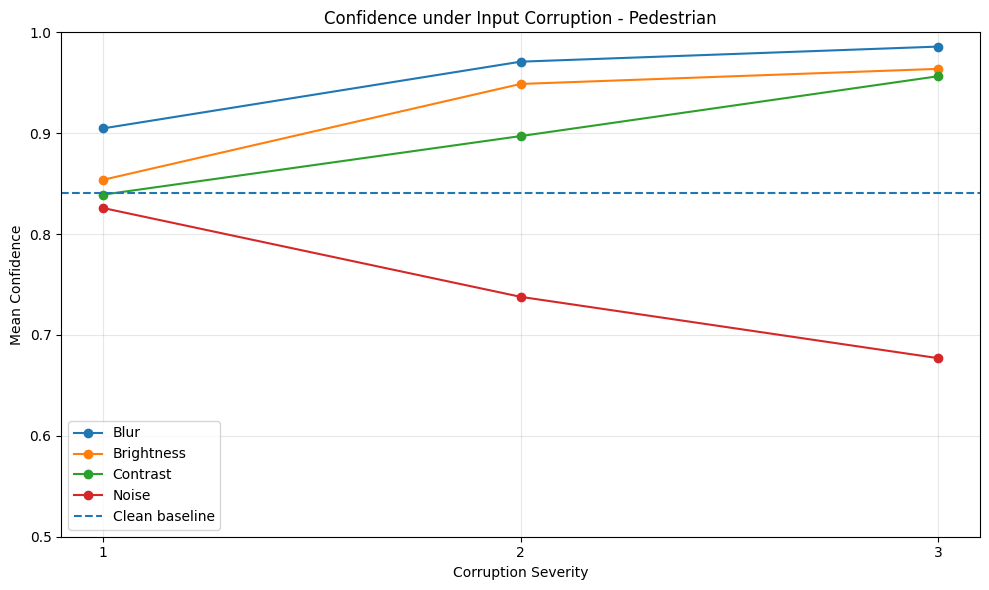

Saved: ../results/additional_implementation\pedestrian_icr_confidence.png


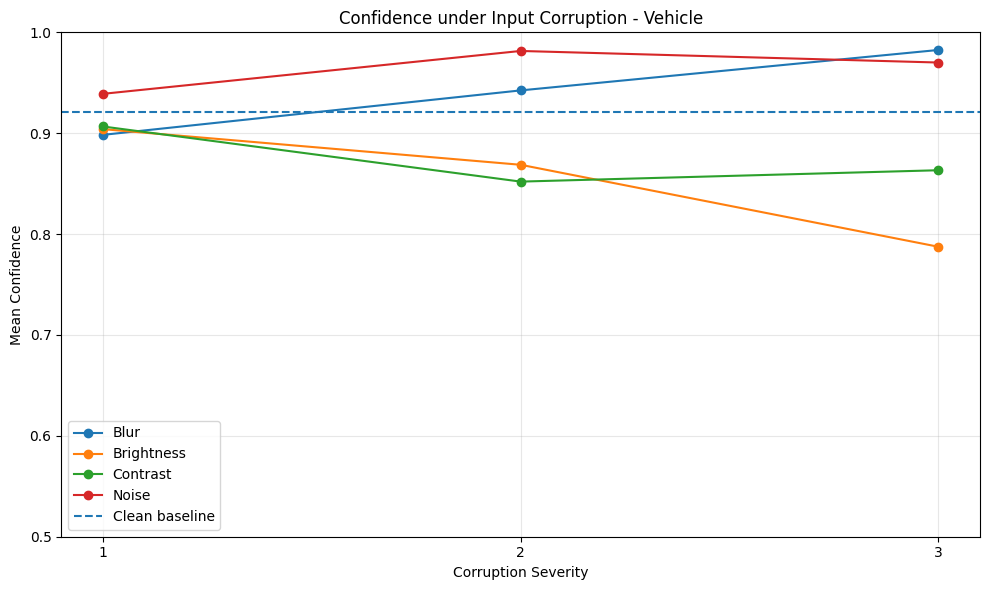

Saved: ../results/additional_implementation\vehicle_icr_confidence.png


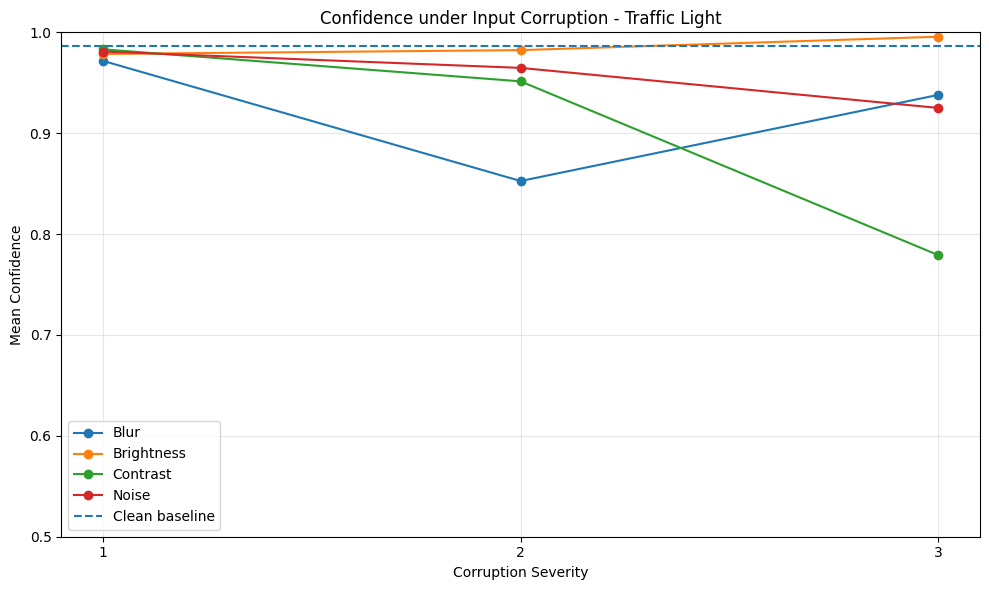

Saved: ../results/additional_implementation\traffic_light_icr_confidence.png


In [19]:
#Mean confidence degradation

for model_name in all_icr_results["Model"].unique():

    model_data = all_icr_results[
        all_icr_results["Model"] == model_name
    ]


    plt.figure(
        figsize=(10, 6)
    )


    for corruption in corruptions.keys():

        corruption_data = model_data[
            model_data["Corruption"] == corruption
        ]


        plt.plot(

            corruption_data["Severity"],

            corruption_data["Mean Confidence"],

            marker="o",

            label=corruption.capitalize()

        )


    clean_confidence = model_data[
        model_data["Corruption"] == "None"
    ]["Mean Confidence"].iloc[0]


    plt.axhline(

        clean_confidence,

        linestyle="--",

        label="Clean baseline"

    )


    plt.xlabel(
        "Corruption Severity"
    )

    plt.ylabel(
        "Mean Confidence"
    )

    plt.title(
        f"Confidence under Input Corruption - {model_name}"
    )

    plt.xticks(
        [1, 2, 3]
    )

    plt.ylim(
        0.5,
        1.0
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    filename = (

        model_name.lower()
        .replace(" ", "_")
        + "_icr_confidence.png"

    )


    output_path = os.path.join(

        RESULTS_DIR,

        filename

    )


    plt.savefig(

        output_path,

        bbox_inches="tight"

    )


    plt.show()

    plt.close()


    print(
        "Saved:",
        output_path
    )

In [20]:
#worst corruption for each model

# Find the condition that causes the largest recall drop for each model.

worst_cases = []


for model_name in icr_results_df["Model"].unique():

    model_data = icr_results_df[
        icr_results_df["Model"] == model_name
    ]


    worst_row = model_data.loc[
        model_data["Recall Drop"].idxmax()
    ]


    worst_cases.append({

        "Model": model_name,

        "Worst Corruption":
            worst_row["Corruption"],

        "Severity":
            worst_row["Severity"],

        "Recall":
            worst_row["Recall"],

        "Recall Drop":
            worst_row["Recall Drop"],

        "Mean Confidence":
            worst_row["Mean Confidence"]

    })


worst_cases_df = pd.DataFrame(
    worst_cases
)


worst_cases_df

,Model,Worst Corruption,Severity,Recall,Recall Drop,Mean Confidence
0,Pedestrian,brightness,3,0.008499,0.501416,0.963794
1,Vehicle,brightness,3,0.014815,0.950370,0.787471
2,Traffic Light,brightness,3,0.000000,0.984133,0.995651


In [21]:
#compact summary of the strongest degradation
# observed for each perception model.

summary_rows = []


for model_name in icr_results_df["Model"].unique():

    model_data = icr_results_df[
        icr_results_df["Model"] == model_name
    ]


    clean_row = all_icr_results[
        (
            all_icr_results["Model"] == model_name
        )
        &
        (
            all_icr_results["Corruption"] == "None"
        )
    ].iloc[0]


    worst_row = model_data.loc[
        model_data["Recall Drop"].idxmax()
    ]


    summary_rows.append({

        "Model": model_name,

        "Clean Recall":
            clean_row["Recall"],

        "Worst Corruption":
            worst_row["Corruption"],

        "Worst Severity":
            worst_row["Severity"],

        "Worst Recall":
            worst_row["Recall"],

        "Maximum Recall Drop":
            worst_row["Recall Drop"],

        "Confidence at Worst Case":
            worst_row["Mean Confidence"]

    })


icr_summary_df = pd.DataFrame(
    summary_rows
)


icr_summary_df

,Model,Clean Recall,Worst Corruption,Worst Severity,Worst Recall,Maximum Recall Drop,Confidence at Worst Case
0,Pedestrian,0.509915,brightness,3,0.008499,0.501416,0.963794
1,Vehicle,0.965185,brightness,3,0.014815,0.950370,0.787471
2,Traffic Light,0.984133,brightness,3,0.000000,0.984133,0.995651


In [22]:
summary_path = os.path.join(

    RESULTS_DIR,

    "input_corruption_robustness_summary.csv"

)


icr_summary_df.to_csv(

    summary_path,

    index=False

)


print(
    "Summary saved to:",
    summary_path
)

Summary saved to: ../results/additional_implementation\input_corruption_robustness_summary.csv


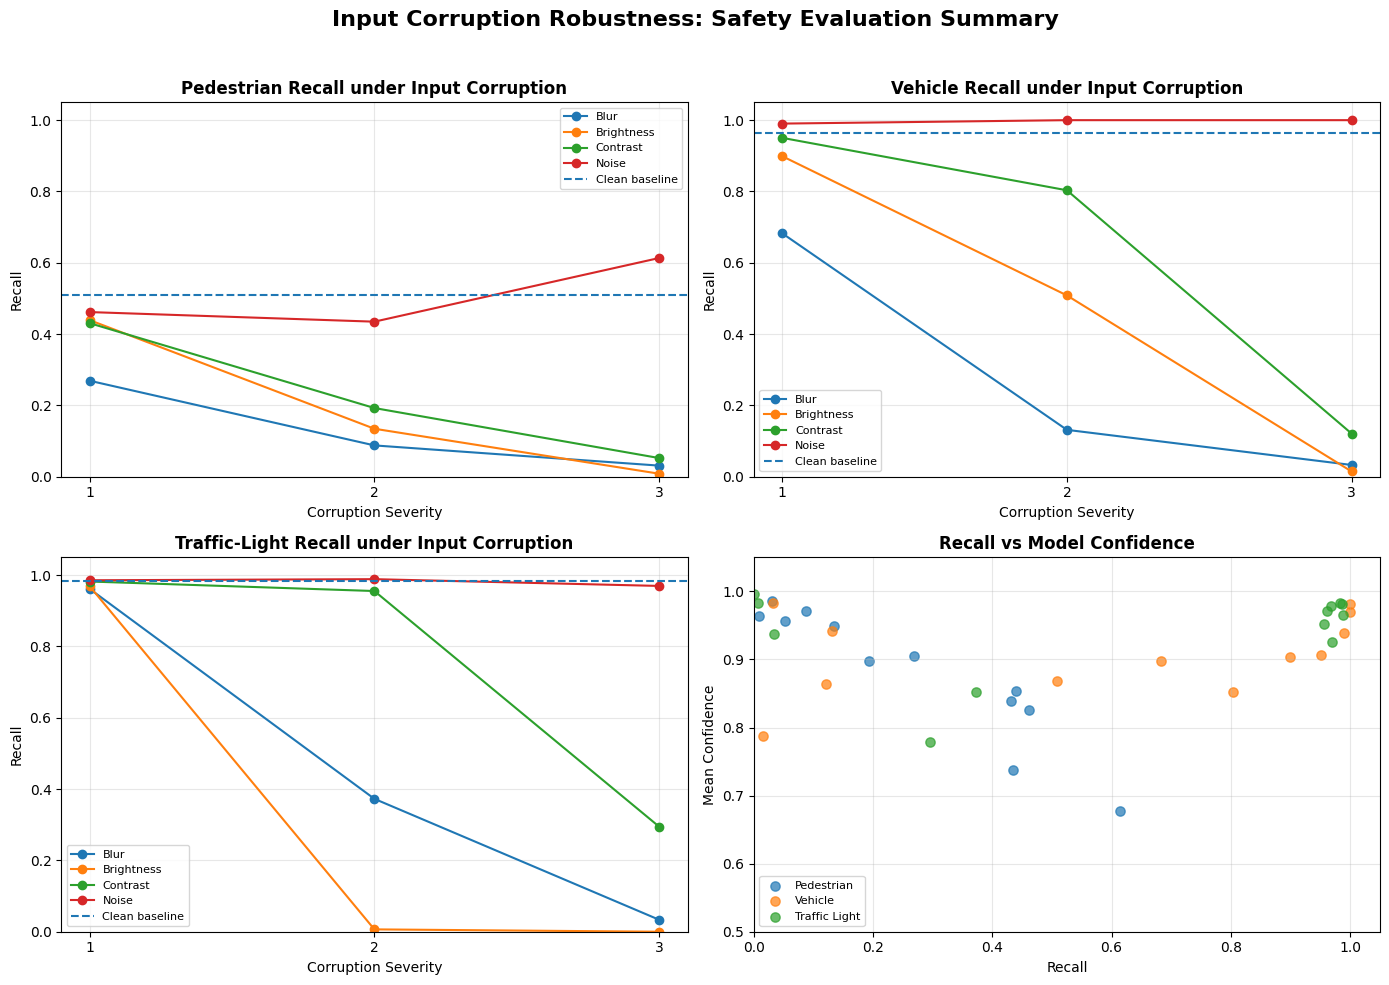

Final ICR summary figure saved to:
../results/additional_implementation\ICR_final_summary.png


In [23]:
#COmbined results for report conclusion

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)



# 1. Pedestrian Recall under Corruption


ax = axes[0, 0]

model_name = "Pedestrian"

model_data = all_icr_results[
    all_icr_results["Model"] == model_name
]

for corruption in corruptions.keys():

    data = model_data[
        model_data["Corruption"] == corruption
    ]

    ax.plot(
        data["Severity"],
        data["Recall"],
        marker="o",
        label=corruption.capitalize()
    )


# Keep the clean model performance as the reference.

clean_recall = model_data[
    model_data["Corruption"] == "None"
]["Recall"].iloc[0]

ax.axhline(
    clean_recall,
    linestyle="--",
    label="Clean baseline"
)

ax.set_title(
    "Pedestrian Recall under Input Corruption",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Corruption Severity"
)

ax.set_ylabel(
    "Recall"
)

ax.set_xticks(
    [1, 2, 3]
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    alpha=0.3
)

ax.legend(
    fontsize=8
)



# 2. Vehicle Recall under Corruption


ax = axes[0, 1]

model_name = "Vehicle"

model_data = all_icr_results[
    all_icr_results["Model"] == model_name
]

for corruption in corruptions.keys():

    data = model_data[
        model_data["Corruption"] == corruption
    ]

    ax.plot(
        data["Severity"],
        data["Recall"],
        marker="o",
        label=corruption.capitalize()
    )


clean_recall = model_data[
    model_data["Corruption"] == "None"
]["Recall"].iloc[0]

ax.axhline(
    clean_recall,
    linestyle="--",
    label="Clean baseline"
)

ax.set_title(
    "Vehicle Recall under Input Corruption",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Corruption Severity"
)

ax.set_ylabel(
    "Recall"
)

ax.set_xticks(
    [1, 2, 3]
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    alpha=0.3
)

ax.legend(
    fontsize=8
)



# 3. Traffic-Light Recall under Corruption


ax = axes[1, 0]

model_name = "Traffic Light"

model_data = all_icr_results[
    all_icr_results["Model"] == model_name
]

for corruption in corruptions.keys():

    data = model_data[
        model_data["Corruption"] == corruption
    ]

    ax.plot(
        data["Severity"],
        data["Recall"],
        marker="o",
        label=corruption.capitalize()
    )


clean_recall = model_data[
    model_data["Corruption"] == "None"
]["Recall"].iloc[0]

ax.axhline(
    clean_recall,
    linestyle="--",
    label="Clean baseline"
)

ax.set_title(
    "Traffic-Light Recall under Input Corruption",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Corruption Severity"
)

ax.set_ylabel(
    "Recall"
)

ax.set_xticks(
    [1, 2, 3]
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    alpha=0.3
)

ax.legend(
    fontsize=8
)



# 4. Recall vs Confidence


ax = axes[1, 1]

# This panel shows the important safety finding:
# performance can collapse even when confidence remains high.

for model_name in all_icr_results["Model"].unique():

    model_data = all_icr_results[
        all_icr_results["Model"] == model_name
    ]

    # Ignore the clean baseline here because we want to
    # focus on the corrupted inputs.

    corrupted_data = model_data[
        model_data["Corruption"] != "None"
    ]

    ax.scatter(
        corrupted_data["Recall"],
        corrupted_data["Mean Confidence"],
        s=45,
        alpha=0.7,
        label=model_name
    )


ax.set_title(
    "Recall vs Model Confidence",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Mean Confidence"
)

ax.set_xlim(
    0,
    1.05
)

ax.set_ylim(
    0.5,
    1.05
)

ax.grid(
    alpha=0.3
)

ax.legend(
    fontsize=8
)



# Overall figure


fig.suptitle(
    "Input Corruption Robustness: Safety Evaluation Summary",
    fontsize=16,
    fontweight="bold"
)


# Give the title enough space.

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)


# Save the final figure at high resolution for the report.

final_icr_path = os.path.join(
    RESULTS_DIR,
    "ICR_final_summary.png"
)

plt.savefig(
    final_icr_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "Final ICR summary figure saved to:"
)

print(
    final_icr_path
)

Safety Envelope Evaluation

This experiment builds directly on the Input Corruption Robustness results by identifying the boundary at which model performance becomes insufficient for safe operation. The existing clean and corrupted CARLA test images are evaluated across different decision thresholds to analyze the tradeoff between recall and false positivies

The analysis uses recall drop relative to the clean baseline as the primary safety criterion, with a 10% maximum drop adopted from the robustness criterion used in the safety-case walkthrough. 

The objective is to identify combinations of input degradation and decision threshold that remain within the acceptable performance region and to determine whether confidence-based thresholds can reliably distinguish safe from unsafe predictions.

In [24]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [25]:
print("Test images:", len(test_df))

print(
    "Models:",
    [model_name for model_name, _, _ in models_info]
)

print(
    "Test directory:",
    TEST_DIR
)

Test images: 3600
Models: ['Pedestrian', 'Vehicle', 'Traffic Light']
Test directory: ../datasets/test/rgb-front


In [26]:
# The safety-case walkthrough uses a recall-drop criterion of less than 10%.
MAX_ALLOWED_RECALL_DROP = 0.10

# These are decision thresholds that we will test.
# 0.5 is the standard threshold already used in the project.
# Lower values favour recall and therefore reduce false negatives.

DECISION_THRESHOLDS = np.array([
    0.01,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
])


print(
    "Maximum allowed recall drop:",
    MAX_ALLOWED_RECALL_DROP
)

print(
    "Decision thresholds:",
    DECISION_THRESHOLDS
)

Maximum allowed recall drop: 0.1
Decision thresholds: [0.01 0.05 0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9 ]


In [27]:
# Collecting the model probability for every test image and keeping individual probabilities to evaluate many thresholds later.

def collect_predictions(
    model,
    dataset,
    batch_size=64
):

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )


    probabilities = []

    labels = []


    model.eval()


    with torch.no_grad():

        for images, batch_labels in loader:

            images = images.to(
                device
            )


            # Get the raw model output.

            logits = model(
                images
            ).flatten()


            # Convert the logits into probabilities.

            probs = torch.sigmoid(
                logits
            )


            probabilities.extend(
                probs.cpu().numpy()
            )


            labels.extend(
                batch_labels.numpy()
            )


    return (
        np.array(probabilities),
        np.array(labels).astype(int)
    )

In [28]:
#Using the same clean and corrupted images to directly compare the results with Input Corruption Robustness results

evaluation_conditions = [

    {
        "name": "Clean",
        "corruption": None,
        "severity": 0
    }

]


# Add the four ICR corruption types.

for corruption, severity_levels in corruptions.items():

    for severity in severity_levels:

        evaluation_conditions.append({

            "name": (
                f"{corruption.capitalize()} "
                f"S{severity}"
            ),

            "corruption": corruption,

            "severity": severity

        })


print(
    "Number of evaluation conditions:",
    len(evaluation_conditions)
)

Number of evaluation conditions: 13


In [29]:
# Run each model once for every clean/corrupted condition.
# The individual probabilities are stored for the threshold sweep.

prediction_cache = {}


for model_name, model, target in models_info:

    print(
        f"\n=============================="
    )

    print(
        f"Collecting predictions: {model_name}"
    )

    print(
        f"=============================="
    )


    prediction_cache[model_name] = {}


    for condition in evaluation_conditions:

        condition_name = condition["name"]


        print(
            f"  {condition_name}"
        )


        # Use the original dataset for the clean condition.

        if condition["corruption"] is None:

            dataset = CarlaDataset(

                test_df,

                TEST_DIR,

                target

            )


        # Use the corrupted dataset for ICR conditions.

        else:

            dataset = CorruptedCarlaDataset(

                test_df,

                TEST_DIR,

                target,

                condition["corruption"],

                condition["severity"]

            )


        probabilities, labels = collect_predictions(

            model,

            dataset

        )


        prediction_cache[model_name][
            condition_name
        ] = {

            "probabilities": probabilities,

            "labels": labels

        }


print(
    "\nAll predictions collected successfully."
)


  Clean
  Blur S1
  Blur S2
  Blur S3
  Brightness S1
  Brightness S2
  Brightness S3
  Contrast S1
  Contrast S2
  Contrast S3
  Noise S1
  Noise S2
  Noise S3

  Clean
  Blur S1
  Blur S2
  Blur S3
  Brightness S1
  Brightness S2
  Brightness S3
  Contrast S1
  Contrast S2
  Contrast S3
  Noise S1
  Noise S2
  Noise S3

  Clean
  Blur S1
  Blur S2
  Blur S3
  Brightness S1
  Brightness S2
  Brightness S3
  Contrast S1
  Contrast S2
  Contrast S3
  Noise S1
  Noise S2
  Noise S3

All predictions collected successfully.


In [30]:
# Every condition contains the expected number of predictions.

for model_name in prediction_cache:

    print(
        f"\n{model_name}"
    )


    for condition_name in prediction_cache[model_name]:

        number_of_predictions = len(
            prediction_cache[model_name][
                condition_name
            ]["probabilities"]
        )


        print(
            f"{condition_name}: "
            f"{number_of_predictions}"
        )


Pedestrian
Clean: 3600
Blur S1: 3600
Blur S2: 3600
Blur S3: 3600
Brightness S1: 3600
Brightness S2: 3600
Brightness S3: 3600
Contrast S1: 3600
Contrast S2: 3600
Contrast S3: 3600
Noise S1: 3600
Noise S2: 3600
Noise S3: 3600

Vehicle
Clean: 3600
Blur S1: 3600
Blur S2: 3600
Blur S3: 3600
Brightness S1: 3600
Brightness S2: 3600
Brightness S3: 3600
Contrast S1: 3600
Contrast S2: 3600
Contrast S3: 3600
Noise S1: 3600
Noise S2: 3600
Noise S3: 3600

Traffic Light
Clean: 3600
Blur S1: 3600
Blur S2: 3600
Blur S3: 3600
Brightness S1: 3600
Brightness S2: 3600
Brightness S3: 3600
Contrast S1: 3600
Contrast S2: 3600
Contrast S3: 3600
Noise S1: 3600
Noise S2: 3600
Noise S3: 3600


In [31]:
# Evaluate one set of probabilities at a particular decision threshold.

def evaluate_threshold(
    probabilities,
    labels,
    threshold
):

    predictions = (
        probabilities >= threshold
    ).astype(int)


    # True positives: pedestrian/object correctly detected.

    true_positive = np.sum(
        (labels == 1) &
        (predictions == 1)
    )


    # False negatives: object present but missed.
    # This is the safety-critical error.

    false_negative = np.sum(
        (labels == 1) &
        (predictions == 0)
    )


    # False positives: object predicted when absent.

    false_positive = np.sum(
        (labels == 0) &
        (predictions == 1)
    )


    true_negative = np.sum(
        (labels == 0) &
        (predictions == 0)
    )


    # Calculate recall.

    positive_count = (
        true_positive +
        false_negative
    )


    if positive_count > 0:

        recall = (
            true_positive /
            positive_count
        )

    else:

        recall = 0.0


    # Calculate precision.

    predicted_positive = (
        true_positive +
        false_positive
    )


    if predicted_positive > 0:

        precision = (
            true_positive /
            predicted_positive
        )

    else:

        precision = 0.0


    # Calculate F1.

    if (
        precision + recall
    ) > 0:

        f1 = (
            2 *
            precision *
            recall
            /
            (precision + recall)
        )

    else:

        f1 = 0.0


    return {

        "Recall": recall,

        "Precision": precision,

        "F1": f1,

        "TP": true_positive,

        "FN": false_negative,

        "FP": false_positive,

        "TN": true_negative

    }

In [32]:
# Evaluate all three models across all corruption conditions and all decision thresholds.

safety_envelope_results = []


for model_name in prediction_cache:

    print(
        f"\nProcessing {model_name}..."
    )


    # Get the clean probabilities and labels.

    clean_data = prediction_cache[
        model_name
    ]["Clean"]


    clean_probabilities = clean_data[
        "probabilities"
    ]

    clean_labels = clean_data[
        "labels"
    ]


    # Calculate clean recall for every threshold.
    # This is important because recall depends on the threshold.

    clean_threshold_metrics = {}


    for threshold in DECISION_THRESHOLDS:

        metrics = evaluate_threshold(

            clean_probabilities,

            clean_labels,

            threshold

        )


        clean_threshold_metrics[
            threshold
        ] = metrics["Recall"]


    # Evaluate every condition.

    for condition_name in prediction_cache[
        model_name
    ]:

        condition_data = prediction_cache[
            model_name
        ][condition_name]


        probabilities = condition_data[
            "probabilities"
        ]

        labels = condition_data[
            "labels"
        ]


        for threshold in DECISION_THRESHOLDS:

            metrics = evaluate_threshold(

                probabilities,

                labels,

                threshold

            )


            clean_recall = clean_threshold_metrics[
                threshold
            ]


            # Recall drop relative to clean data
            # at the SAME decision threshold.

            recall_drop = (
                clean_recall -
                metrics["Recall"]
            )


            # The envelope criterion is satisfied when
            # the recall drop is no more than 10%.

            envelope_met = (
                recall_drop <=
                MAX_ALLOWED_RECALL_DROP
            )


            safety_envelope_results.append({

                "Model": model_name,

                "Condition": condition_name,

                "Threshold": threshold,

                "Recall": metrics["Recall"],

                "Precision": metrics["Precision"],

                "F1": metrics["F1"],

                "TP": metrics["TP"],

                "FN": metrics["FN"],

                "FP": metrics["FP"],

                "TN": metrics["TN"],

                "Clean Recall":
                    clean_recall,

                "Recall Drop":
                    recall_drop,

                "Envelope Met":
                    envelope_met

            })


safety_envelope_df = pd.DataFrame(
    safety_envelope_results
)


print(
    "\nSafety Envelope evaluation completed."
)

print(
    "Rows:",
    len(safety_envelope_df)
)


Processing Pedestrian...

Processing Vehicle...

Processing Traffic Light...

Safety Envelope evaluation completed.
Rows: 429


In [33]:
# Show the results at the original 0.5 decision threshold.

standard_threshold_results = safety_envelope_df[
    safety_envelope_df["Threshold"] == 0.50
].copy()


standard_threshold_results[
    [
        "Model",
        "Condition",
        "Recall",
        "Clean Recall",
        "Recall Drop",
        "Envelope Met"
    ]
]

,Model,Condition,Recall,Clean Recall,Recall Drop,Envelope Met
6,Pedestrian,Clean,0.509915,0.509915,0.000000,True
17,Pedestrian,Blur S1,0.269122,0.509915,0.240793,False
28,Pedestrian,Blur S2,0.087819,0.509915,0.422096,False
39,Pedestrian,Blur S3,0.031161,0.509915,0.478754,False
50,Pedestrian,Brightness S1,0.439093,0.509915,0.070822,True
61,Pedestrian,Brightness S2,0.134561,0.509915,0.375354,False
72,Pedestrian,Brightness S3,0.008499,0.509915,0.501416,False
83,Pedestrian,Contrast S1,0.430595,0.509915,0.079320,True
94,Pedestrian,Contrast S2,0.192635,0.509915,0.317280,False
105,Pedestrian,Contrast S3,0.052408,0.509915,0.457507,False


In [34]:
# Counting how many tested conditions remain inside the safety envelope for each model and threshold.

threshold_summary = (

    safety_envelope_df

    .groupby(
        [
            "Model",
            "Threshold"
        ]
    )

    .agg(

        Conditions_Met=(
            "Envelope Met",
            "sum"
        ),

        Total_Conditions=(
            "Envelope Met",
            "count"
        ),

        Minimum_Recall=(
            "Recall",
            "min"
        ),

        Maximum_Recall_Drop=(
            "Recall Drop",
            "max"
        )

    )

    .reset_index()

)


threshold_summary[
    "Envelope Coverage"
] = (

    threshold_summary["Conditions_Met"]

    /

    threshold_summary["Total_Conditions"]

)


threshold_summary

,Model,Threshold,Conditions_Met,Total_Conditions,Minimum_Recall,Maximum_Recall_Drop,Envelope Coverage
0,Pedestrian,0.01,11,13,0.464589,0.516997,0.846154
1,Pedestrian,0.05,6,13,0.089235,0.815864,0.461538
2,Pedestrian,0.10,6,13,0.042493,0.808782,0.461538
3,Pedestrian,0.20,6,13,0.025496,0.699717,0.461538
4,Pedestrian,0.30,6,13,0.015581,0.627479,0.461538
5,Pedestrian,0.40,6,13,0.011331,0.572238,0.461538
6,Pedestrian,0.50,6,13,0.008499,0.501416,0.461538
7,Pedestrian,0.60,5,13,0.002833,0.453258,0.384615
8,Pedestrian,0.70,5,13,0.001416,0.407932,0.384615
9,Pedestrian,0.80,4,13,0.001416,0.352691,0.307692


In [35]:
# Find thresholds that satisfy the envelope for every tested condition.

fully_covered_thresholds = threshold_summary[
    threshold_summary["Conditions_Met"]
    ==
    threshold_summary["Total_Conditions"]
].copy()


fully_covered_thresholds

,Model,Threshold,Conditions_Met,Total_Conditions,Minimum_Recall,Maximum_Recall_Drop,Envelope Coverage


In [36]:
# Finding the conditions with the largest recall degradation.

worst_envelope_cases = (

    safety_envelope_df

    .sort_values(
        "Recall Drop",
        ascending=False
    )

    .head(20)

)


worst_envelope_cases[
    [
        "Model",
        "Condition",
        "Threshold",
        "Recall",
        "Clean Recall",
        "Recall Drop",
        "Envelope Met"
    ]
]

,Model,Condition,Threshold,Recall,Clean Recall,Recall Drop,Envelope Met
353,Traffic Light,Brightness S3,0.05,0.000000,0.996904,0.996904,False
354,Traffic Light,Brightness S3,0.10,0.000000,0.994195,0.994195,False
355,Traffic Light,Brightness S3,0.20,0.000000,0.991486,0.991486,False
356,Traffic Light,Brightness S3,0.30,0.000000,0.988003,0.988003,False
352,Traffic Light,Brightness S3,0.01,0.010836,0.998452,0.987616,False
357,Traffic Light,Brightness S3,0.40,0.000000,0.985294,0.985294,False
358,Traffic Light,Brightness S3,0.50,0.000000,0.984133,0.984133,False
359,Traffic Light,Brightness S3,0.60,0.000000,0.983746,0.983746,False
360,Traffic Light,Brightness S3,0.70,0.000000,0.982585,0.982585,False
361,Traffic Light,Brightness S3,0.80,0.000000,0.980263,0.980263,False


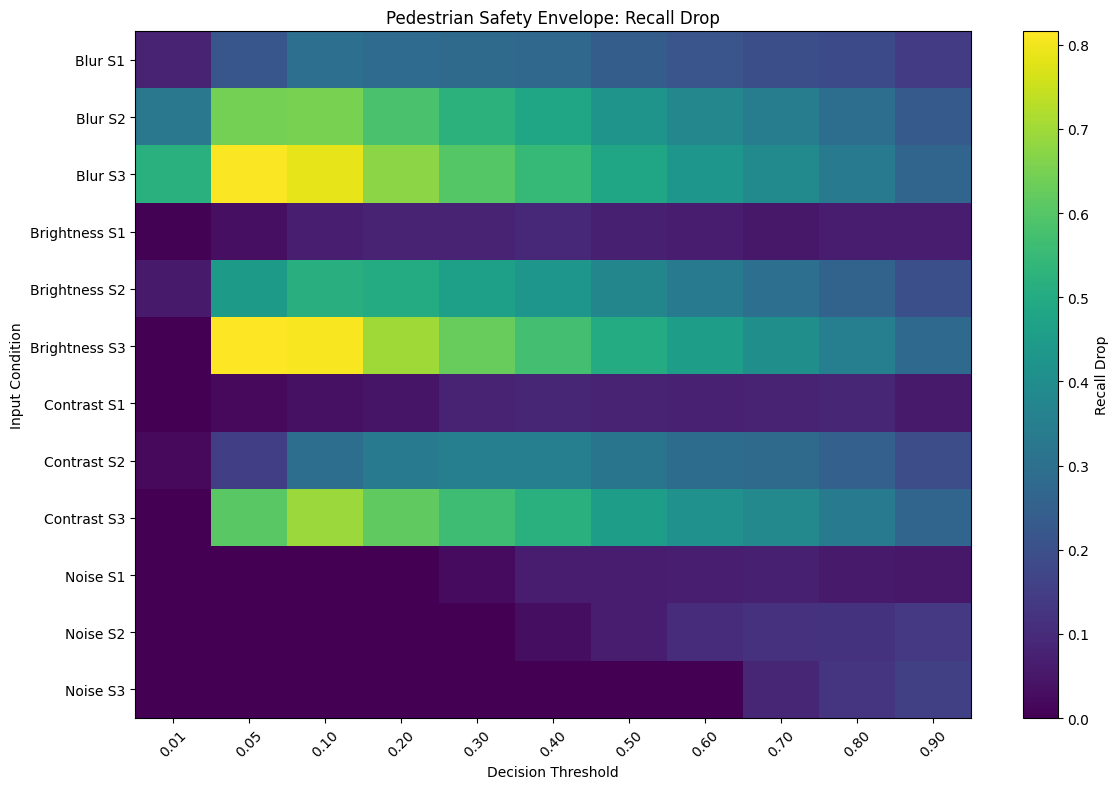

Saved: ../results/additional_implementation\safety_envelope_pedestrian.png


In [37]:
# Visualize the pedestrian safety envelope.
# Green/inside means the recall drop stays within 10%.
# Outside means the degradation exceeds the analytical boundary.

model_name = "Pedestrian"


pedestrian_envelope = safety_envelope_df[
    safety_envelope_df["Model"] == model_name
]


# Remove the clean condition because it is the reference baseline.

pedestrian_envelope = pedestrian_envelope[
    pedestrian_envelope["Condition"] != "Clean"
]


# Create a matrix:
# rows = corruption conditions
# columns = decision thresholds

envelope_matrix = (

    pedestrian_envelope

    .pivot(
        index="Condition",
        columns="Threshold",
        values="Recall Drop"
    )

)


plt.figure(
    figsize=(12, 8)
)


plt.imshow(
    envelope_matrix.values,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=max(
        0.10,
        np.nanmax(
            envelope_matrix.values
        )
    )
)


plt.colorbar(
    label="Recall Drop"
)


plt.xticks(
    range(
        len(envelope_matrix.columns)
    ),
    [
        f"{x:.2f}"
        for x in envelope_matrix.columns
    ],
    rotation=45
)


plt.yticks(
    range(
        len(envelope_matrix.index)
    ),
    envelope_matrix.index
)


plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Input Condition"
)

plt.title(
    "Pedestrian Safety Envelope: Recall Drop"
)


# Mark the 10% boundary directly on the plot.

plt.tight_layout()


heatmap_path = os.path.join(
    RESULTS_DIR,
    "safety_envelope_pedestrian.png"
)


plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "Saved:",
    heatmap_path
)

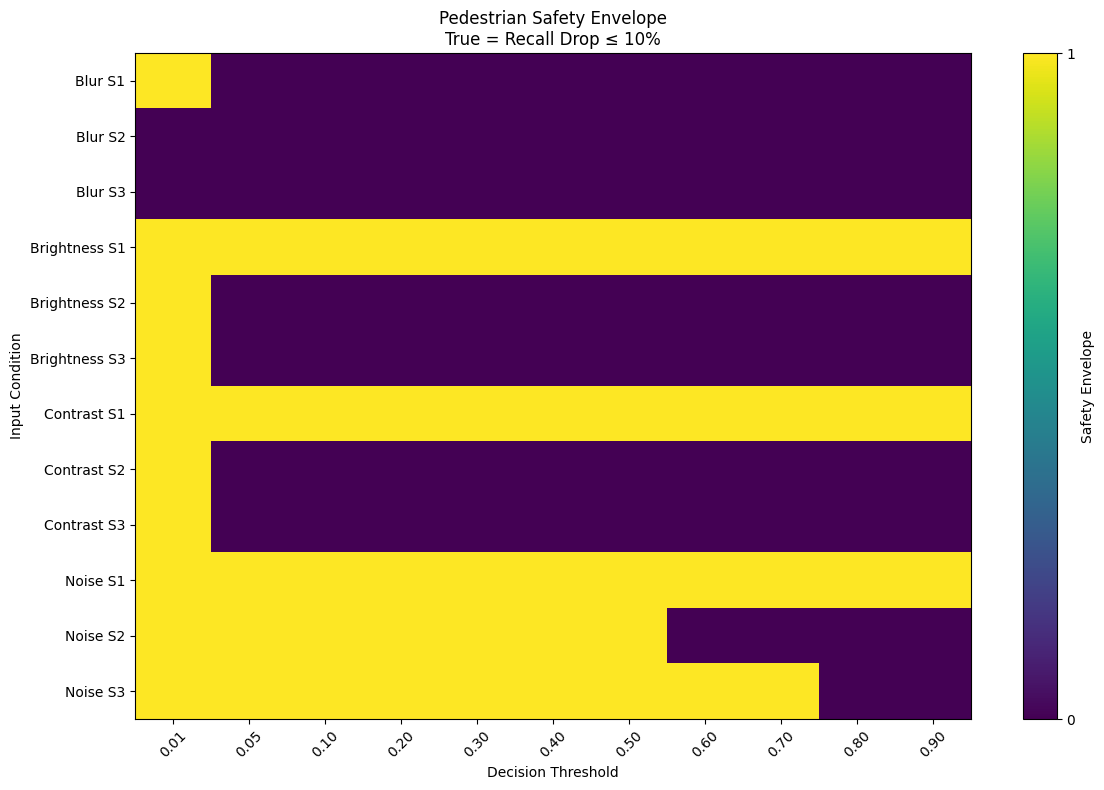

Saved: ../results/additional_implementation\safety_envelope_pedestrian_binary.png


In [38]:
# Convert the recall-drop results into a simple safe/unsafe map.
# This makes the safety boundary much easier to interpret.

pedestrian_binary = (

    pedestrian_envelope

    .pivot(
        index="Condition",
        columns="Threshold",
        values="Recall Drop"
    )

    <= MAX_ALLOWED_RECALL_DROP

)


plt.figure(
    figsize=(12, 8)
)


plt.imshow(
    pedestrian_binary.values,
    aspect="auto",
    interpolation="nearest"
)


plt.xticks(
    range(
        len(pedestrian_binary.columns)
    ),
    [
        f"{x:.2f}"
        for x in pedestrian_binary.columns
    ],
    rotation=45
)


plt.yticks(
    range(
        len(pedestrian_binary.index)
    ),
    pedestrian_binary.index
)


plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Input Condition"
)

plt.title(
    "Pedestrian Safety Envelope\n"
    "True = Recall Drop ≤ 10%"
)


plt.colorbar(
    ticks=[0, 1],
    label="Safety Envelope"
)


plt.tight_layout()


binary_heatmap_path = os.path.join(
    RESULTS_DIR,
    "safety_envelope_pedestrian_binary.png"
)


plt.savefig(
    binary_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "Saved:",
    binary_heatmap_path
)

In [39]:
# Calculating the confidence of each individual prediction and confidence is the probability assigned to the predicted class.

def calculate_confidence(
    probabilities
):

    return np.maximum(
        probabilities,
        1 - probabilities
    )

In [40]:
# TDefining confidence thresholds

CONFIDENCE_THRESHOLDS = np.array([

    0.50,
    0.60,
    0.70,
    0.80,
    0.85,
    0.90,
    0.95,
    0.97,
    0.98,
    0.99,
    0.995

])


print(
    "Confidence thresholds:",
    CONFIDENCE_THRESHOLDS
)

Confidence thresholds: [0.5   0.6   0.7   0.8   0.85  0.9   0.95  0.97  0.98  0.99  0.995]


In [41]:
# Measuring whether confidence can catch false negatives

confidence_monitor_results = []


for model_name in prediction_cache:

    for condition_name in prediction_cache[
        model_name
    ]:

        data = prediction_cache[
            model_name
        ][condition_name]


        probabilities = data[
            "probabilities"
        ]

        labels = data[
            "labels"
        ]


        predictions = (
            probabilities >= 0.5
        ).astype(int)


        confidence = calculate_confidence(
            probabilities
        )


        # Identify the actual false negatives
        # produced at the standard threshold.

        false_negative_mask = (
            (labels == 1)
            &
            (predictions == 0)
        )


        total_false_negatives = np.sum(
            false_negative_mask
        )


        for threshold in CONFIDENCE_THRESHOLDS:

            # A fallback is triggered when confidence
            # falls below the selected threshold.

            fallback_mask = (
                confidence < threshold
            )


            # How many of the false negatives would
            # actually have been caught by the monitor?

            caught_false_negatives = np.sum(

                false_negative_mask
                &
                fallback_mask

            )


            if total_false_negatives > 0:

                fn_detection_rate = (

                    caught_false_negatives
                    /
                    total_false_negatives

                )

            else:

                fn_detection_rate = 0.0


            fallback_rate = np.mean(
                fallback_mask
            )


            confidence_monitor_results.append({

                "Model": model_name,

                "Condition": condition_name,

                "Confidence Threshold":
                    threshold,

                "False Negatives":
                    total_false_negatives,

                "False Negatives Caught":
                    caught_false_negatives,

                "FN Detection Rate":
                    fn_detection_rate,

                "Fallback Rate":
                    fallback_rate

            })


confidence_monitor_df = pd.DataFrame(
    confidence_monitor_results
)


confidence_monitor_df.head()

,Model,Condition,Confidence Threshold,False Negatives,False Negatives Caught,FN Detection Rate,Fallback Rate
0,Pedestrian,Clean,0.50,346,0,0.000000,0.000000
1,Pedestrian,Clean,0.60,346,52,0.150289,0.099167
2,Pedestrian,Clean,0.70,346,94,0.271676,0.199722
3,Pedestrian,Clean,0.80,346,152,0.439306,0.338611
4,Pedestrian,Clean,0.85,346,190,0.549133,0.423333


In [42]:
#examining the dangerous confidence cases

confidence_failure_analysis = (

    confidence_monitor_df[

        confidence_monitor_df[
            "False Negatives"
        ] > 0

    ]

    .sort_values(
        [
            "Model",
            "Condition",
            "Confidence Threshold"
        ]

    )

)


confidence_failure_analysis[
    [
        "Model",
        "Condition",
        "Confidence Threshold",
        "False Negatives",
        "False Negatives Caught",
        "FN Detection Rate",
        "Fallback Rate"
    ]
].head(30)

,Model,Condition,Confidence Threshold,False Negatives,False Negatives Caught,FN Detection Rate,Fallback Rate
11,Pedestrian,Blur S1,0.500,516,0,0.000000,0.000000
12,Pedestrian,Blur S1,0.600,516,27,0.052326,0.046389
13,Pedestrian,Blur S1,0.700,516,66,0.127907,0.095278
14,Pedestrian,Blur S1,0.800,516,120,0.232558,0.183889
15,Pedestrian,Blur S1,0.850,516,154,0.298450,0.230556
16,Pedestrian,Blur S1,0.900,516,201,0.389535,0.293611
17,Pedestrian,Blur S1,0.950,516,294,0.569767,0.424167
18,Pedestrian,Blur S1,0.970,516,372,0.720930,0.545833
19,Pedestrian,Blur S1,0.980,516,405,0.784884,0.655833
20,Pedestrian,Blur S1,0.990,516,448,0.868217,0.778333


In [43]:
#here focusing on severe ICR condiitons i.e S3

severe_conditions = [

    "Blur S3",

    "Brightness S3",

    "Contrast S3",

    "Noise S3"

]


severe_confidence_results = confidence_monitor_df[
    confidence_monitor_df["Condition"].isin(
        severe_conditions
    )
]


severe_confidence_results[
    [
        "Model",
        "Condition",
        "Confidence Threshold",
        "False Negatives",
        "False Negatives Caught",
        "FN Detection Rate",
        "Fallback Rate"
    ]
]

,Model,Condition,Confidence Threshold,False Negatives,False Negatives Caught,FN Detection Rate,Fallback Rate
33,Pedestrian,Blur S3,0.500,684,0,0.000000,0.000000
34,Pedestrian,Blur S3,0.600,684,5,0.007310,0.001944
35,Pedestrian,Blur S3,0.700,684,7,0.010234,0.004167
36,Pedestrian,Blur S3,0.800,684,14,0.020468,0.006667
37,Pedestrian,Blur S3,0.850,684,18,0.026316,0.009444
...,...,...,...,...,...,...,...
424,Traffic Light,Noise S3,0.950,74,71,0.959459,0.303889
425,Traffic Light,Noise S3,0.970,74,74,1.000000,0.355000
426,Traffic Light,Noise S3,0.980,74,74,1.000000,0.398611
427,Traffic Light,Noise S3,0.990,74,74,1.000000,0.470278


In [44]:
# Save the complete threshold-sweep results.

safety_envelope_csv = os.path.join(

    RESULTS_DIR,

    "safety_envelope_results.csv"

)


safety_envelope_df.to_csv(

    safety_envelope_csv,

    index=False

)


# Save the threshold summary separately.

threshold_summary_csv = os.path.join(

    RESULTS_DIR,

    "safety_envelope_threshold_summary.csv"

)


threshold_summary.to_csv(

    threshold_summary_csv,

    index=False

)


# Save the confidence-monitor analysis.

confidence_monitor_csv = os.path.join(

    RESULTS_DIR,

    "safety_envelope_confidence_analysis.csv"

)


confidence_monitor_df.to_csv(

    confidence_monitor_csv,

    index=False

)


print(
    "Safety Envelope results saved."
)

print(
    safety_envelope_csv
)

print(
    threshold_summary_csv
)

print(
    confidence_monitor_csv
)

Safety Envelope results saved.
../results/additional_implementation\safety_envelope_results.csv
../results/additional_implementation\safety_envelope_threshold_summary.csv
../results/additional_implementation\safety_envelope_confidence_analysis.csv


In [45]:
# Create a compact summary of the worst observed condition
# at the standard 0.5 decision threshold.

standard_results = safety_envelope_df[
    safety_envelope_df["Threshold"] == 0.50
]


summary_rows = []


for model_name in standard_results[
    "Model"
].unique():

    model_data = standard_results[
        standard_results["Model"] == model_name
    ]


    # Ignore clean data when looking for degradation.

    corrupted_data = model_data[
        model_data["Condition"] != "Clean"
    ]


    worst_case = corrupted_data.loc[
        corrupted_data["Recall Drop"].idxmax()
    ]


    summary_rows.append({

        "Model": model_name,

        "Worst Condition":
            worst_case["Condition"],

        "Clean Recall":
            worst_case["Clean Recall"],

        "Worst Recall":
            worst_case["Recall"],

        "Recall Drop":
            worst_case["Recall Drop"],

        "Envelope Met":
            worst_case["Envelope Met"]

    })


safety_envelope_summary = pd.DataFrame(
    summary_rows
)


safety_envelope_summary

,Model,Worst Condition,Clean Recall,Worst Recall,Recall Drop,Envelope Met
0,Pedestrian,Brightness S3,0.509915,0.008499,0.501416,False
1,Vehicle,Brightness S3,0.965185,0.014815,0.950370,False
2,Traffic Light,Brightness S3,0.984133,0.000000,0.984133,False


In [46]:
# Save the compact summary for later use in the report.

summary_path = os.path.join(

    RESULTS_DIR,

    "safety_envelope_summary.csv"

)


safety_envelope_summary.to_csv(

    summary_path,

    index=False

)


print(
    "Summary saved to:",
    summary_path
)

Summary saved to: ../results/additional_implementation\safety_envelope_summary.csv


Runtime Safety Monitor

The Runtime Safety Monitor extends the previous ICR and Safety Envelope experiments by introducing a simple runtime mechanism for detecting potentially unsafe perception conditions.

Confidence alone is not sufficient as a safety trigger so the monitor therefore combines the model confidence with simple image-quality indicators derived from the camera input. When the perception output is uncertain or the input is outside the observed quality range, the monitor flags the frame and activates a simulated safe fallback.

The experiment evaluates how often unsafe corrupted inputs are detected while also measuring unnecessary fallback activations on clean inputs.

In [48]:
# Runtime monitor settings.
# 0.60 was already used as a confidence threshold in Exercise 5.

CONFIDENCE_THRESHOLD = 0.60

#clean test set to define the normal image-quality range.

QUALITY_PERCENTILE = 5

print("Confidence threshold:", CONFIDENCE_THRESHOLD)
print("Image-quality percentile:", QUALITY_PERCENTILE)

Confidence threshold: 0.6
Image-quality percentile: 5


In [49]:
# Calculate two simple indicators of camera-image quality.

def image_quality(image):

    # Average pixel intensity gives a simple brightness measure.

    brightness = image.mean().item()

    # Convert RGB to grayscale for the sharpness calculation.

    gray = (
        0.299 * image[0]
        + 0.587 * image[1]
        + 0.114 * image[2]
    )

    # Image gradients give a simple measure of sharpness.

    dx = gray[:, 1:] - gray[:, :-1]
    dy = gray[1:, :] - gray[:-1, :]

    sharpness = (
        dx.var().item()
        +
        dy.var().item()
    )

    return brightness, sharpness

In [50]:
# Measure image quality across the clean test set.
# These values represent the normal input distribution.

quality_values = []


for idx in range(len(test_df)):

    image, _ = ped_test[idx]

    brightness, sharpness = image_quality(
        image
    )

    quality_values.append({
        "Brightness": brightness,
        "Sharpness": sharpness
    })


quality_df = pd.DataFrame(
    quality_values
)


# Define conservative lower limits using the clean distribution.

brightness_min = np.percentile(
    quality_df["Brightness"],
    QUALITY_PERCENTILE
)

sharpness_min = np.percentile(
    quality_df["Sharpness"],
    QUALITY_PERCENTILE
)


print(
    f"Normal brightness limit: {brightness_min:.4f}"
)

print(
    f"Normal sharpness limit: {sharpness_min:.6f}"
)

Normal brightness limit: 0.5380
Normal sharpness limit: 0.003151


In [51]:
# The monitor flags a frame when either the model is uncertain or the camera input looks significantly degraded.

def runtime_safety_monitor(
    probability,
    brightness,
    sharpness
):

    confidence = max(
        probability,
        1 - probability
    )


    low_confidence = (
        confidence < CONFIDENCE_THRESHOLD
    )


    degraded_input = (

        brightness < brightness_min

        or

        sharpness < sharpness_min

    )


    # Either warning signal is sufficient to trigger fallback.

    fallback = (
        low_confidence
        or
        degraded_input
    )


    if fallback:

        status = "FALLBACK"

    else:

        status = "NORMAL"


    return {
        "Confidence": confidence,
        "Low Confidence": low_confidence,
        "Degraded Input": degraded_input,
        "Fallback": fallback,
        "Status": status
    }

In [52]:
# Evaluate the runtime monitor on the pedestrian detector. The monitor is tested on clean and corrupted inputs.

monitor_results = []


pedestrian_model.eval()


for condition in evaluation_conditions:

    condition_name = condition["name"]


    # Use the clean dataset or the corresponding corrupted dataset.

    if condition["corruption"] is None:

        dataset = CarlaDataset(
            test_df,
            TEST_DIR,
            "has_pedestrian"
        )

    else:

        dataset = CorruptedCarlaDataset(
            test_df,
            TEST_DIR,
            "has_pedestrian",
            condition["corruption"],
            condition["severity"]
        )


    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False
    )


    fallback_count = 0
    total_count = 0


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            probabilities = torch.sigmoid(
                pedestrian_model(images)
            ).flatten().cpu().numpy()


            for image, probability in zip(
                images.cpu(),
                probabilities
            ):

                brightness, sharpness = image_quality(
                    image
                )


                monitor = runtime_safety_monitor(
                    probability,
                    brightness,
                    sharpness
                )


                fallback_count += int(
                    monitor["Fallback"]
                )

                total_count += 1


    fallback_rate = (
        fallback_count /
        total_count
    )


    monitor_results.append({

        "Condition": condition_name,

        "Fallback Count":
            fallback_count,

        "Total Images":
            total_count,

        "Fallback Rate":
            fallback_rate

    })


runtime_monitor_df = pd.DataFrame(
    monitor_results
)


runtime_monitor_df

,Condition,Fallback Count,Total Images,Fallback Rate
0,Clean,702,3600,0.195000
1,Blur S1,3383,3600,0.939722
2,Blur S2,3600,3600,1.000000
3,Blur S3,3600,3600,1.000000
4,Brightness S1,3330,3600,0.925000
5,Brightness S2,3600,3600,1.000000
6,Brightness S3,3600,3600,1.000000
7,Contrast S1,2613,3600,0.725833
8,Contrast S2,3600,3600,1.000000
9,Contrast S3,3600,3600,1.000000


In [53]:
# Compare fallback activation between clean and corrupted conditions.

runtime_monitor_df[
    [
        "Condition",
        "Fallback Rate"
    ]
]

,Condition,Fallback Rate
0,Clean,0.195000
1,Blur S1,0.939722
2,Blur S2,1.000000
3,Blur S3,1.000000
4,Brightness S1,0.925000
5,Brightness S2,1.000000
6,Brightness S3,1.000000
7,Contrast S1,0.725833
8,Contrast S2,1.000000
9,Contrast S3,1.000000


In [54]:
# Clean fallback activations represent unnecessary safety interventions.

clean_fallback_rate = runtime_monitor_df[
    runtime_monitor_df["Condition"] == "Clean"
]["Fallback Rate"].iloc[0]


corrupted_fallback_rate = runtime_monitor_df[
    runtime_monitor_df["Condition"] != "Clean"
]["Fallback Rate"].mean()


print(
    f"Clean false-fallback rate: "
    f"{clean_fallback_rate:.3f}"
)

print(
    f"Average corrupted-input fallback rate: "
    f"{corrupted_fallback_rate:.3f}"
)

Clean false-fallback rate: 0.195
Average corrupted-input fallback rate: 0.778


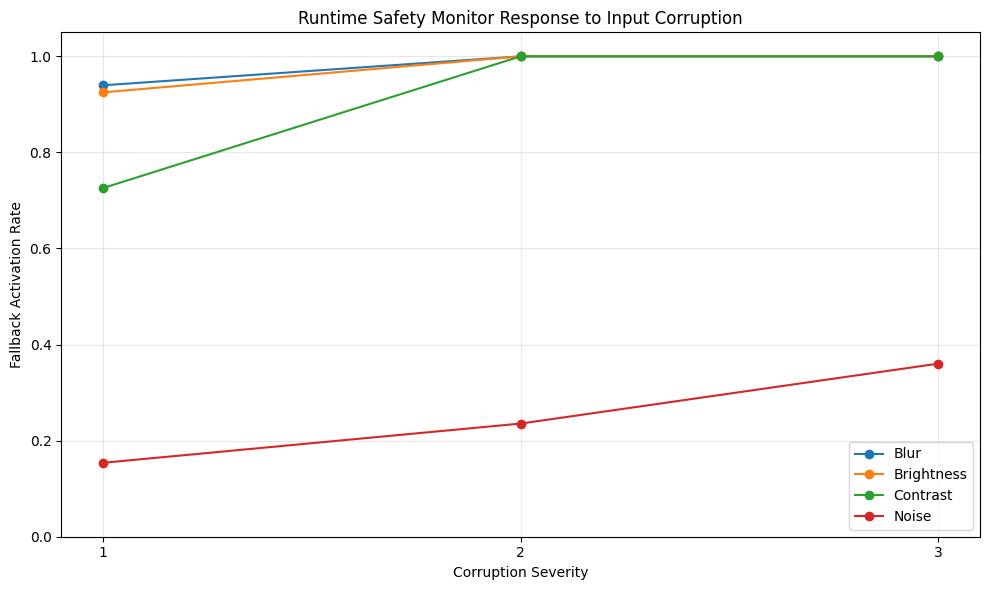

Saved: ../results/additional_implementation\runtime_safety_monitor.png


In [55]:
# frequency of the runtime monitor activates as corruption severity increases.

plot_df = runtime_monitor_df[
    runtime_monitor_df["Condition"] != "Clean"
].copy()


plot_df["Corruption"] = (
    plot_df["Condition"]
    .str.extract(
        r"([A-Za-z]+)"
    )[0]
)


plot_df["Severity"] = (
    plot_df["Condition"]
    .str.extract(
        r"S([0-9]+)"
    )[0]
    .astype(int)
)


plt.figure(
    figsize=(10, 6)
)


for corruption in corruptions.keys():

    data = plot_df[
        plot_df["Corruption"].str.lower()
        == corruption
    ]


    plt.plot(
        data["Severity"],
        data["Fallback Rate"],
        marker="o",
        label=corruption.capitalize()
    )


plt.xlabel(
    "Corruption Severity"
)

plt.ylabel(
    "Fallback Activation Rate"
)

plt.title(
    "Runtime Safety Monitor Response to Input Corruption"
)

plt.xticks(
    [1, 2, 3]
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


monitor_plot_path = os.path.join(
    RESULTS_DIR,
    "runtime_safety_monitor.png"
)


plt.savefig(
    monitor_plot_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "Saved:",
    monitor_plot_path
)

In [56]:
# Save the monitor evidence for the report and traceability matrix.

monitor_csv_path = os.path.join(
    RESULTS_DIR,
    "runtime_safety_monitor_results.csv"
)


runtime_monitor_df.to_csv(
    monitor_csv_path,
    index=False
)


print(
    "Runtime monitor results saved to:"
)

print(
    monitor_csv_path
)

Runtime monitor results saved to:
../results/additional_implementation\runtime_safety_monitor_results.csv
